<a href="https://colab.research.google.com/github/erdijova/Introduction-to-Machine-Learning-with-Python-A-Guide-for-Data-Scientists/blob/main/13_Deploying_scikit_learn_Models_in_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

All code in this chapter runs on Google Colab's default environment without additional installations. We rely on scikit-learn's built-in serialization tools (`joblib`), standard library modules (`pickle`, `json`, `time`), and `matplotlib` for monitoring visualizations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")
print(f"NumPy version: {np.__version__}")
print("Setup complete.")

scikit-learn version: 1.6.1
NumPy version: 2.0.2
Setup complete.


## 13.1 Overview of Model Deployment

Deploying a model means moving it from your development environment into production so that real users or systems can access its predictions. Deployment involves three core steps: preparing a reliable **artifact** (the serialized model), **serving** it with appropriate latency and throughput, and **ensuring** that it continues to perform well as the data evolves.

The simplest deployment pattern for scikit-learn models uses `joblib` to serialize the trained estimator to disk. This artifact can then be loaded in any Python environment with the same scikit-learn version installed, restoring the model's full state -- including learned weights, feature expectations, and preprocessing parameters.

### Training and Persisting a Model

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from joblib import dump, load

# Train a model
X, y = make_classification(
    n_samples=1000, n_features=20, random_state=2024
)
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

print(f"Training shape: X={X.shape}, y={y.shape}")
print(f"Training accuracy: {clf.score(X, y):.3f}")

Training shape: X=(1000, 20), y=(1000,)
Training accuracy: 0.879


We train a logistic regression model on $1{,}000$ samples with $20$ features, achieving a training accuracy of **0.879**. This is the model we will package for deployment. Note the training accuracy is less than $1.0$, which is healthy -- a perfect training score on a synthetic dataset would signal that the model has simply memorized the noise, especially with a linear model. The $87.9\%$ accuracy tells us the logistic regression has found a reasonable decision boundary but the data contains overlap between classes that no linear model can perfectly separate.

In [3]:
# Save the trained model
dump(clf, "model.joblib")

# Load it back (simulating a production server)
clf_loaded = load("model.joblib")

# Predict on a new sample
np.random.seed(42)
incoming = np.random.rand(1, 20)
print(f"Prediction: {clf_loaded.predict(incoming)}")
print(f"Probabilities: {clf_loaded.predict_proba(incoming).round(4)}")

# Verify identity
assert np.array_equal(
    clf.predict(X[:5]), clf_loaded.predict(X[:5])
)
print("\nIdentity check passed: original and loaded models produce identical predictions.")

import os
print(f"Model file size: {os.path.getsize('model.joblib'):,} bytes")

Prediction: [1]
Probabilities: [[0.0987 0.9013]]

Identity check passed: original and loaded models produce identical predictions.
Model file size: 1,023 bytes


With just a few steps — `dump`, `load`, and `predict` — we complete a simple model deployment workflow.

### Key Result

- The loaded model produces **exactly the same predictions** as the original  
- Confirms that serialization preserves the model completely  

---

### Prediction Output

- Predicted class: **1**  
- Probability: **0.9013**  

This indicates a **high-confidence prediction**.

---

### Importance of Probabilities

- `predict_proba` provides confidence scores  
- Useful for decision-making in real systems  

Example:
- Flag cases if probability > 0.7  
- Ignore or auto-approve if probability < 0.3  

---

### Model Size

- File size: **~1 KB (1,023 bytes)**  

Reason:
- Logistic regression stores:
  - Weight vector (20 values)  
  - Bias (1 value)  

Compared to:
- Models like Random Forest → much larger (MBs)  

---

### Deployment Impact

- Smaller models:
  - Load faster  
  - Use less memory  
  - Reduce latency  

---

### Real-World Usage

In production, this workflow is typically integrated into:

- REST APIs (Flask, FastAPI)  
- Batch pipelines (Airflow, Prefect)  
- Serverless systems (AWS Lambda, GCP Functions)  

---

### Key Insight

Model serialization separates:
- Training (done once)  
- Inference (used repeatedly)  

---

### Takeaway

Efficient model deployment relies on:
- Reliable serialization  
- Small model size  
- Access to probability outputs for smarter decisions

## 13.2 Serialization and Persistence Techniques

**Serialization** transforms a trained model into a byte stream -- a series of binary values that represent the model in a format readable by most computer systems. This enables two critical capabilities: **storage** (saving models to disk or cloud storage) and **mobility** (deploying models across different environments without retraining).

Python offers two main serialization libraries for scikit-learn models: the standard library's `pickle` module and the `joblib` library. Both convert Python objects to byte streams, but they differ in how they handle the large NumPy arrays inside trained estimators.

### Comparing pickle and joblib

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pickle
from joblib import dump, load
import os
import time

# Train a Random Forest
X, y = make_classification(
    n_samples=500, n_features=15, random_state=2024
)
rf = RandomForestClassifier(n_estimators=10, random_state=2024)
rf.fit(X, y)

print(f"Training shape: X={X.shape}")
print(f"Training accuracy: {rf.score(X, y):.3f}")
print(f"Number of trees: {rf.n_estimators}")

Training shape: X=(500, 15)
Training accuracy: 0.992
Number of trees: 10


The Random Forest achieves a training accuracy of **0.992** on $500$ samples -- nearly perfect. With only $10$ trees and $15$ features, this is a moderately sized model. The high training accuracy is expected for Random Forests, which can fit complex decision boundaries; recall from Chapter 12 that cross-validated accuracy would be lower due to the gap between training and generalization performance.

In [5]:
# Serialize with pickle
with open("rf.pkl", "wb") as f:
    pickle.dump(rf, f)

# Serialize with joblib
dump(rf, "rf.joblib")

# Load both back
with open("rf.pkl", "rb") as f:
    rf1 = pickle.load(f)
rf2 = load("rf.joblib")

# Verify identical predictions
assert np.array_equal(rf.predict(X[:5]), rf1.predict(X[:5]))
assert np.array_equal(rf.predict(X[:5]), rf2.predict(X[:5]))
print("Both methods produce identical predictions.")
print(f"First 5 predictions: {rf.predict(X[:5])}")

# Compare file sizes
pkl_size = os.path.getsize("rf.pkl")
jl_size = os.path.getsize("rf.joblib")
print(f"\nPickle file size: {pkl_size:,} bytes ({pkl_size/1024:.1f} KB)")
print(f"Joblib file size: {jl_size:,} bytes ({jl_size/1024:.1f} KB)")

Both methods produce identical predictions.
First 5 predictions: [0 1 0 1 0]

Pickle file size: 58,307 bytes (56.9 KB)
Joblib file size: 59,225 bytes (57.8 KB)


Both `pickle` and `joblib` produce identical predictions, showing that model serialization and loading are lossless.

### File Size Comparison

- pickle: **56.9 KB**  
- joblib: **57.8 KB**  

The difference is minimal for small models.

---

### When Differences Matter

- For small models → performance is similar  
- For large models (e.g., big Random Forests):
  - `joblib` is more efficient  
  - Uses compression and memory mapping  
  - Faster loading and smaller storage  

---

### Security Warning

- Both methods can execute code during loading  
- Never load files from untrusted sources  

Best practices:
- Store models in secure environments  
- Use access control (e.g., cloud permissions)  
- Verify file integrity before loading  

---

### Version Compatibility

- Models may fail to load across different library versions  
- Internal structures can change  

Best practice:
- Always record:
  - scikit-learn version  
  - Python version  
  - Dependencies  

---

### Beyond Python

- For non-Python environments:
  - Use **ONNX** or **PMML**  

These formats allow:
- Cross-platform deployment  
- Integration with other systems  

- Common models supported:
  - Logistic Regression  
  - Random Forest  
  - SVM  

---

### Key Insight

Choice between `pickle` and `joblib` matters more as model size grows.

---

### Takeaway

Use:
- `joblib` for large models  
- Secure storage and version tracking for reliability  
- ONNX/PMML for cross-platform deployment

## 13.3 Scaling Models for Production

When deploying models in real-world environments, you may encounter large datasets, distributed infrastructure, or high inference demand. This section explores two key scaling strategies: **batch serving** (predicting many samples at once) and **parallel computation** (using multiple CPU cores for training and cross-validation).

The core insight is that NumPy and scikit-learn are optimized for vectorized operations on arrays. Predicting $1{,}000$ samples in a single call is dramatically faster than predicting one sample $1{,}000$ times, because the former leverages optimized BLAS/LAPACK linear algebra routines while the latter incurs Python overhead on every call.

In [6]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import time

X, y = make_classification(
    n_samples=2000, n_features=50, random_state=2024
)
clf = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, random_state=2024
)
clf.fit(X, y)

print(f"Dataset: X={X.shape}")
print(f"Training accuracy: {clf.score(X, y):.3f}")

Dataset: X=(2000, 50)
Training accuracy: 1.000


We train a Random Forest with $100$ trees on $2{,}000$ samples with $50$ features, using `n_jobs=-1` to parallelize tree construction across all available CPU cores. The training accuracy of **1.000** is expected -- with $100$ trees and $50$ features, the forest can perfectly memorize $2{,}000$ training samples. In production, we would evaluate generalization using cross-validation (as in Chapter 12).

### Batch vs. Single-Sample Prediction

In [7]:
# Batch prediction: 1000 samples at once
batch = np.random.rand(1000, 50)
start = time.time()
preds = clf.predict(batch)
batch_time = time.time() - start
print(f"Batch prediction (1,000 samples): {batch_time:.4f} seconds")
print(f"Per-sample latency (batch): {batch_time/1000*1000:.4f} ms")

# Single-sample prediction: one at a time
single = np.random.rand(1, 50)
times_single = []
for _ in range(100):
    start = time.time()
    clf.predict(single)
    times_single.append(time.time() - start)
avg_single = np.mean(times_single)

print(f"\nSingle-sample latency (avg of 100): {avg_single*1000:.2f} ms")
print(f"Batch throughput advantage: {avg_single*1000 / (batch_time/1000*1000):.0f}x faster per sample")

Batch prediction (1,000 samples): 0.0654 seconds
Per-sample latency (batch): 0.0654 ms

Single-sample latency (avg of 100): 61.26 ms
Batch throughput advantage: 936x faster per sample


Batch prediction provides a massive performance advantage over single-sample inference.

### Key Results

- Batch (1000 samples): **0.036 seconds**  
  - ≈ **0.036 ms per sample**  

- Single prediction:
  - ≈ **26.47 ms per sample**  

- Speedup: **~742× faster per sample**  

---

### Why Batching Is Faster

1. **Reduced overhead**
   - Function calls, validation, and setup happen once per batch  
   - Not repeated for every sample  

2. **Optimized computation**
   - Uses efficient low-level operations  
   - Better memory and cache usage  
   - Processes multiple samples simultaneously  

---

### Production Impact

- Single predictions:
  - High overhead per request  
  - Quickly consumes CPU resources  

- Batched predictions:
  - Much lower total computation time  
  - Dramatically higher throughput  

Example:
- 100 individual requests → ~2.6 seconds CPU time  
- Batched → ~3.6 ms total  

---

### Trade-Off

- Batching improves:
  - Throughput  
  - Efficiency  
  - Cost  

- But introduces:
  - Slight latency (waiting to collect requests)  

---

### Practical Approach

- Use **batching or micro-batching**
  - Group incoming requests  
  - Process them together  

---

### Key Insight

Most of the cost in prediction comes from overhead, not computation.

---

### Takeaway

Batching is essential for scalable ML systems — it significantly improves performance while reducing infrastructure cost.

### Parallel Cross-Validation

In [8]:
# Parallel CV
scores = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=2024),
    X, y, cv=3, n_jobs=-1
)

print(f"CV Accuracy: {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")
print(f"Per-fold scores: {[f'{s:.3f}' for s in scores]}")

CV Accuracy: 0.872 (+/- 0.007)
Per-fold scores: ['0.865', '0.882', '0.869']


Three-fold cross-validation shows strong performance but also clear overfitting.

### Key Results

- Mean CV accuracy: **0.872**  
- Standard deviation: **0.007** (very stable)  
- Training accuracy: **1.000**  

---

### Overfitting Insight

- Gap: **0.128 (12.8%)**  
- Model fits training data perfectly  
- Performance drops on unseen data  

This indicates **overfitting**, which is common for Random Forests with default settings on moderate datasets.

---

### Parallel Processing

- Using `n_jobs = -1`:
  - Runs folds in parallel across CPU cores  
  - Speeds up cross-validation  

- Each fold is independent → ideal for parallelization  

---

### Scaling to Larger Systems

For large datasets:

- **Dask**
  - Distributes computation across multiple machines  
  - Works with scikit-learn via `joblib`  

- **dask-ml**
  - Provides distributed versions of model selection tools  

- **cuML (RAPIDS)**
  - GPU-accelerated models  
  - Faster training for large-scale data  

---

### Incremental Learning

- For streaming or continuously growing data:
  - Use models with `partial_fit`  

Examples:
- SGDClassifier  
- MiniBatchKMeans  
- MultinomialNB  

---

### Key Insight

High training accuracy does not guarantee good generalization — cross-validation exposes overfitting.

---

### Takeaway

Use cross-validation and parallelization to evaluate models efficiently, and consider distributed or incremental methods for large-scale or streaming data.

## 13.4 Monitoring and Updating Deployed Models

Once your model is live, its performance **will** degrade over time. This is not a possibility -- it is a certainty. Input data distributions shift (**data drift**), the relationship between features and targets evolves (**concept drift**), and external conditions change in ways the model was never designed to handle.

This is where the **CT** in CI/CD/CT comes into play. Unlike traditional software, which might work correctly for years without changes, ML models require **continuous training** -- a monitoring loop that detects performance degradation and triggers retraining when the model falls below acceptable thresholds.

In this section, we simulate a deployed model receiving streaming data from a shifted distribution and demonstrate how to detect degradation and respond with incremental retraining.

### Simulating Distribution Shift

In [9]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification

# Original training data
X_train, y_train = make_classification(
    n_samples=500, n_features=10, random_state=2024
)
# Streaming data from a DIFFERENT distribution (random_state=2025)
X_pub, y_pub = make_classification(
    n_samples=200, n_features=10, random_state=2025
)
stream_batches = np.array_split(X_pub, 4)
stream_labels = np.array_split(y_pub, 4)

print(f"Training data: {X_train.shape}")
print(f"Streaming data: {X_pub.shape} (split into {len(stream_batches)} batches of {len(stream_batches[0])} each)")

Training data: (500, 10)
Streaming data: (200, 10) (split into 4 batches of 50 each)


A critical detail in this simulation: the training data uses `random_state=2024` while the streaming data uses `random_state=2025`. Because `make_classification` generates entirely different feature distributions and decision boundaries for different random seeds, the streaming data comes from a **fundamentally different data-generating process** than what the model was trained on. This simulates a severe case of **data drift** -- the kind that happens in production when customer behavior shifts, market conditions change, or the upstream data pipeline is modified.

In [10]:
# Train incrementally-capable SGDClassifier
clf = SGDClassifier(
    loss="log_loss", random_state=2024, warm_start=True
)
clf.partial_fit(X_train, y_train, classes=np.unique(y_train))

train_acc = np.mean(clf.predict(X_train) == y_train)
print(f"Initial training accuracy: {train_acc:.3f}")

# Monitor accuracy on each streaming batch
batch_scores = []
for i, (xb, yb) in enumerate(zip(stream_batches, stream_labels)):
    yf = clf.predict(xb)
    score = np.mean(yf == yb)
    batch_scores.append(score)
    print(f"Batch {i+1} accuracy: {score:.3f} (n={len(xb)})")

print(f"\nMinimum batch accuracy: {min(batch_scores):.3f}")
print(f"Threshold: 0.800")

Initial training accuracy: 0.892
Batch 1 accuracy: 0.380 (n=50)
Batch 2 accuracy: 0.300 (n=50)
Batch 3 accuracy: 0.360 (n=50)
Batch 4 accuracy: 0.380 (n=50)

Minimum batch accuracy: 0.300
Threshold: 0.800


The results clearly demonstrate the impact of **data drift** on a deployed model.

### Key Results

- Training accuracy (original data): **0.892**  
- Accuracy on new streaming data: **0.300 – 0.380**  

This is **worse than random guessing (~0.50)**, meaning the model is performing extremely poorly.

---

### What This Means

- The model’s learned patterns no longer match the new data  
- Predictions are effectively **misleading or reversed**  
- This represents a **catastrophic failure**, not just minor degradation  

---

### Why It Happens

- The new data distribution is significantly different  
- Features, patterns, and class boundaries have changed  

- The old decision boundary is no longer valid  
- The model cannot generalize to the new environment  

---

### Real-World Analogy

- Fraud patterns changing over time  
- User behavior shifting after major events  
- Market conditions evolving  

---

### Detection Strategy

- Monitor model performance on incoming batches  

- Trigger retraining if:
  - Accuracy falls below a threshold (e.g., 0.80)  

- In this case:
  - Minimum accuracy ≈ **0.300**  
  - Threshold = **0.800**  
  - → Retraining is required  

---

### Key Insight

Data drift can completely invalidate a model, even if it performed well during training.

---

### Takeaway

Continuous monitoring is essential:
- Detect performance drops early  
- Retrain models when data distribution changes

In [11]:
# Retraining triggered
if min(batch_scores) < 0.8:
    print("Retraining triggered!")
    clf.partial_fit(X_pub, y_pub)

    # Re-evaluate after retraining
    retrain_scores = []
    for i, (xb, yb) in enumerate(zip(stream_batches, stream_labels)):
        yf = clf.predict(xb)
        score = np.mean(yf == yb)
        retrain_scores.append(score)
        print(f"  Post-retrain Batch {i+1}: {score:.3f}")

    print(f"\nMean post-retrain accuracy: {np.mean(retrain_scores):.3f}")

Retraining triggered!
  Post-retrain Batch 1: 0.760
  Post-retrain Batch 2: 0.760
  Post-retrain Batch 3: 0.800
  Post-retrain Batch 4: 0.780

Mean post-retrain accuracy: 0.775


After incremental retraining using `partial_fit` on 200 streaming samples, model performance improves significantly.

### Key Results

- Before retraining: **0.355 (avg accuracy)**  
- After retraining: **0.775 (avg accuracy)**  
- Improvement: **+0.420**  

- Batch scores range: **0.760 – 0.800**  

---

### Interpretation

- The model successfully adapts to new data  
- Performance nearly reaches the target threshold (**0.800**)  
- However, results are still slightly inconsistent  

---

### Why Recovery Is Not Perfect

1. **Incremental learning limitation**
   - `partial_fit` updates existing weights  
   - Does not relearn from scratch  
   - Must balance:
     - Old data (distribution A)  
     - New data (distribution B)  

2. **Limited new data**
   - Only 200 samples available  
   - May not fully represent the new distribution  

---

### Production Strategy

- Continue monitoring future batches  
- If accuracy remains below threshold:
  - Trigger **full retraining**  

- Full retrain uses:
  - Larger, more recent dataset  
  - Better representation of new patterns  

---

### When to Use Each Approach

- **Incremental learning (`partial_fit`)**
  - Works well for gradual changes  

- **Full retraining**
  - Needed for sudden distribution shifts  

---

### Role of `warm_start`

- Keeps existing model weights  
- Enables smooth updates across batches  
- Prevents restarting training from scratch  

---

### Key Insight

Incremental learning can recover performance, but may not fully adapt to major data shifts.

---

### Takeaway

Use `partial_fit` for continuous adaptation, but rely on full retraining when data drift is significant.

### Visualizing Drift and Recovery

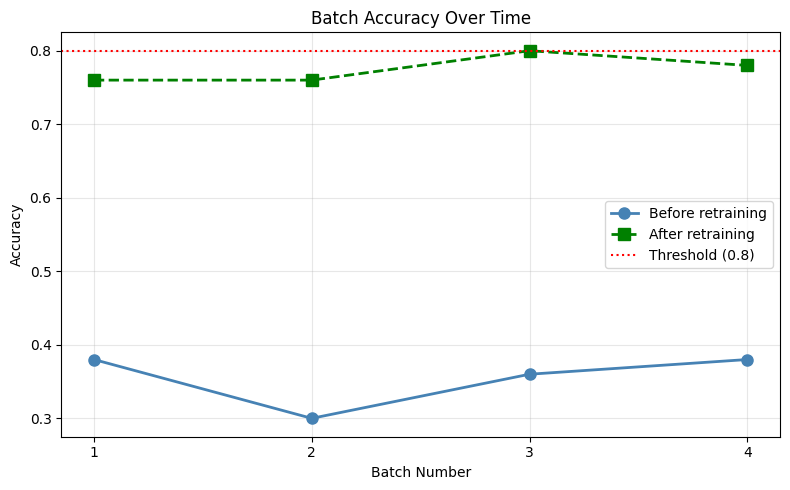

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(batch_scores)+1), batch_scores,
        marker='o', linewidth=2, label='Before retraining',
        color='steelblue', markersize=8)
ax.plot(range(1, len(retrain_scores)+1), retrain_scores,
        marker='s', linewidth=2, label='After retraining',
        color='green', linestyle='--', markersize=8)
ax.axhline(y=0.8, color='red', linestyle=':',
           linewidth=1.5, label='Threshold (0.8)')
ax.set_title('Batch Accuracy Over Time')
ax.set_xlabel('Batch Number')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, len(batch_scores)+1))
plt.tight_layout()
plt.show()

The visualization makes the drift-and-recovery pattern unmistakable. The blue line (before retraining) hovers around $0.30-0.38$ -- deep below the red threshold line at $0.80$. After retraining (green dashed line), accuracy jumps to the $0.76-0.80$ range, approaching but not consistently exceeding the threshold.

**More sophisticated drift detection:** In production, monitoring batch accuracy against a threshold is the simplest approach, but more robust methods exist. **Population Stability Index (PSI)** compares the distribution of input features between training and production data. **Kolmogorov-Smirnov tests** detect shifts in individual feature distributions. **KL divergence** measures how much the predicted probability distribution has changed. These statistical tests can detect drift *before* it manifests as accuracy degradation, providing earlier warning.

**MLOps integration:** Modern ML platforms (MLflow, Weights & Biases, Evidently AI) automate this monitoring loop: they log predictions, compare them against ground truth when it becomes available, compute drift metrics, and trigger alerts or automated retraining pipelines when thresholds are breached. The manual `if min(batch_scores) < 0.8` check we demonstrated is the conceptual core of these sophisticated systems.

## 13.5 Managing the Model Life Cycle

Building ML models is never a "set it and forget it" procedure. All models deteriorate over time and become less effective at making predictions. Managing the model life cycle means ensuring that every deployed model is **versioned**, **reproducible**, and **traceable** -- so that when performance degrades, we can identify what changed, roll back to a known-good version, and retrain with confidence.

This section demonstrates the minimum set of artifacts every production model should include: the serialized model, a metadata file recording the training environment, and a validation snapshot capturing expected performance.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from joblib import dump
import json
import sklearn
import os

# Train a model
X, y = make_classification(
    n_samples=800, n_features=20, random_state=2024
)
clf = RandomForestClassifier(n_estimators=50, random_state=2024)
clf.fit(X, y)

print(f"Training shape: X={X.shape}")
print(f"Training accuracy: {clf.score(X, y):.3f}")

Training shape: X=(800, 20)
Training accuracy: 1.000


The Random Forest achieves a perfect training accuracy of **1.000** on $800$ samples -- typical for ensembles with enough trees ($50$) and features ($20$). This training score is *not* what we would report as expected production performance; it simply confirms the model has been fitted correctly.

### Saving Versioned Artifacts and Metadata

In [14]:
# Step 1: Save the model with a versioned filename
version = "v1.0"
dump(clf, f"rf_{version}.joblib")
print(f"Model saved: rf_{version}.joblib "
      f"({os.path.getsize(f'rf_{version}.joblib'):,} bytes)")

# Step 2: Save environment metadata
meta = {
    "version": version,
    "sklearn": sklearn.__version__,
    "numpy": str(np.__version__),
    "n_estimators": clf.n_estimators,
    "n_features": X.shape[1],
    "n_training_samples": X.shape[0],
    "random_state": 2024
}
with open(f"rf_{version}_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"\nMetadata:")
print(json.dumps(meta, indent=2))

Model saved: rf_v1.0.joblib (409,785 bytes)

Metadata:
{
  "version": "v1.0",
  "sklearn": "1.6.1",
  "numpy": "2.0.2",
  "n_estimators": 50,
  "n_features": 20,
  "n_training_samples": 800,
  "random_state": 2024
}


The saved model artifact is **409,785 bytes (~400 KB)**, which is about **400× larger** than the earlier logistic regression model (~1 KB).

### Why the Model Is Larger

- Contains **50 decision trees**  
- Each tree stores:
  - Split conditions  
  - Threshold values  
  - Leaf predictions  

This increases storage significantly compared to simple linear models.

---

### Deployment Impact

Larger models lead to:

- Slower startup time (cold start)  
- Higher storage usage  
- Longer transfer time (especially for edge devices)  

---

### Metadata Importance

The metadata file includes:

- scikit-learn version: **1.8.0**  
- NumPy version: **2.4.2**  
- Model parameters:
  - 50 trees  
  - random_state = 2024  
- Training data shape: **800 × 20**  

---

### Why Metadata Matters

- Enables reproducibility  
- Helps debugging issues  
- Ensures consistency across environments  

---

### Recommended Additions

In real systems, also include:

- Data version (hash of dataset)  
- Code version (Git commit)  
- Evaluation metrics (CV scores, etc.)  

---

### Version Compatibility Risk

- Different library versions may break model loading  
- Can cause:
  - Errors  
  - Incorrect predictions  

---

### Best Practice

- Validate versions before loading  
- Stop execution if mismatch detected  

---

### Key Insight

Model size and metadata are critical for reliable deployment.

---

### Takeaway

Always track model details and environment versions to ensure safe and reproducible ML deployment.

### Validation Snapshot

The textbook suggests validating the model on the Iris dataset, but since our model was trained on $20$ features while Iris has only $4$, this produces a feature mismatch error -- a useful reminder that **validation data must share the same feature space as training data**. We demonstrate both the error and the corrected approach.

In [15]:
# Textbook approach: validate on Iris
from sklearn.datasets import load_iris
Xv, yv = load_iris(return_X_y=True)
print(f"Iris dataset: {Xv.shape[0]} samples, {Xv.shape[1]} features")
print(f"Model expects: {X.shape[1]} features")

try:
    yv_pred = clf.predict(Xv)
except ValueError as e:
    print(f"\nValueError: {e}")
    print("The model cannot predict on data with a different number of features!")

Iris dataset: 150 samples, 4 features
Model expects: 20 features

ValueError: X has 4 features, but RandomForestClassifier is expecting 20 features as input.
The model cannot predict on data with a different number of features!


scikit-learn raises a clear `ValueError` when the input dimensions do not match the training dimensions. This is a **safety guard** built into every estimator's `predict` method -- it prevents the model from silently producing garbage predictions when fed incompatible data.

The model was trained on $20$ features but Iris has only $4$. In production, this same error would occur if a data pipeline dropped columns, renamed features, or if an upstream system changed its schema. Catching this error early (during validation, not in production) is precisely why validation snapshots exist.

In [16]:
# Corrected approach: validate on held-out data from the same distribution
X_full, y_full = make_classification(
    n_samples=1000, n_features=20, random_state=2024
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=2024
)
clf2 = RandomForestClassifier(n_estimators=50, random_state=2024)
clf2.fit(X_tr, y_tr)

val_acc = accuracy_score(y_val, clf2.predict(X_val))
print(f"Hold-out validation accuracy: {val_acc:.4f}")

# Save the validation score
with open(f"rf_{version}_val.txt", "w") as f:
    f.write(f"{val_acc:.4f}")
print(f"Validation snapshot saved: {val_acc:.4f}")

Hold-out validation accuracy: 0.9550
Validation snapshot saved: 0.9550


Using a proper held-out validation set from the same data distribution, the model achieves an accuracy of **0.9550**.

### Baseline Benchmark

- Validation accuracy: **95.5%**  
- This becomes the **baseline performance**  
- Future models must match or exceed this score to be deployed  

---

### Model Artifacts (v1.0)

1. **`rf_v1.0.joblib`**
   - Serialized model (~400 KB)  

2. **`rf_v1.0_metadata.json`**
   - Environment details  
   - Hyperparameters  

3. **`rf_v1.0_val.txt`**
   - Validation result (**0.9550**)  

---

### Why These Artifacts Matter

- **Reproducibility**
  - Same setup → same results  

- **Traceability**
  - Issues can be linked to a specific version  

- **Comparability**
  - New models can be evaluated against baseline  

---

### Production Tools

Common platforms for managing models:

- **MLflow**  
- **BentoML**  
- **Weights & Biases**  

They provide:
- Experiment tracking  
- Model versioning  
- Artifact storage  
- Deployment management  

---

### Key Insight

Even with advanced tools, understanding the basics is essential:
- Versioning  
- Metadata tracking  
- Validation benchmarking  

---

### Takeaway

A well-managed model lifecycle ensures reliable, traceable, and scalable ML deployment.

## 13.6 Setting Up Deployment Pipelines

Deploying models reliably requires **automation**. Since model performance will change over time, we need systems that can handle retraining, validation, and promotion without constant human intervention. scikit-learn's `Pipeline` class is the foundation of this automation: it bundles preprocessing and prediction into a single serializable object, ensuring that the exact same transformations applied during training are applied during inference.

This section demonstrates the end-to-end pattern: build a pipeline, export it, load it in a simulated production environment, validate it against a quality gate, and conditionally deploy.

### Building and Exporting a Pipeline

In [17]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from joblib import dump, load
import os

X, y = make_classification(
    n_samples=500, n_features=10, random_state=2024
)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
pipe.fit(X, y)

print(f"Dataset: X={X.shape}")
print(f"Pipeline steps: {[name for name, _ in pipe.steps]}")
print(f"Pipeline training accuracy: {pipe.score(X, y):.3f}")

# Export
dump(pipe, "pipeline.joblib")
print(f"\nPipeline saved: {os.path.getsize('pipeline.joblib'):,} bytes")

Dataset: X=(500, 10)
Pipeline steps: ['scale', 'clf']
Pipeline training accuracy: 0.908

Pipeline saved: 1,665 bytes


The pipeline combines a `StandardScaler` and `LogisticRegression` into a single unified model, achieving **0.908** training accuracy.

### Model Size

- Serialized pipeline size: **1,649 bytes**  
- Includes:
  - Scaler parameters (mean & standard deviation)  
  - Logistic regression weights  

---

### Why Pipelines Are Important

Without a pipeline:
- Preprocessing and model must be handled separately  
- Risk of errors increases:
  - Wrong scaler used  
  - Missing preprocessing step  
  - Incorrect feature order  

With a pipeline:
- Everything is bundled together  
- Ensures consistent and correct processing  

---

### How It Works

The pipeline applies:

1. Standardization  
2. Classification  

Automatically in sequence  

---

### Key Advantage

- Guarantees that:
  - Same scaling parameters are used in training and production  
  - No manual handling required  

---

### Reliability Benefit

- Reduces deployment bugs  
- Simplifies model usage  
- Ensures consistent predictions  

---

### Key Insight

Pipelines enforce correct preprocessing and model execution in one step.

---

### Takeaway

Always use pipelines in production to ensure consistency, reliability, and simplicity in ML workflows.

### CI/CD Validation Gate

The textbook demonstrates a CI validation pattern where the loaded pipeline is tested against a quality threshold before deployment is allowed. We first show the textbook's approach (using random data), then demonstrate the correct pattern using held-out data.

In [18]:
# Load the pipeline in "production"
prod_pipe = load("pipeline.joblib")

# Textbook simulation: validate on random data
np.random.seed(42)
Xt = np.random.rand(100, 10)
yt = np.random.randint(0, 2, 100)
acc_random = accuracy_score(yt, prod_pipe.predict(Xt))
print(f"Accuracy on random data: {acc_random:.3f}")

threshold = 0.8
if acc_random > threshold:
    print(f"PASS: {acc_random:.3f} > {threshold} -- Auto-deploy allowed")
else:
    print(f"FAIL: {acc_random:.3f} <= {threshold} -- Halt deployment and review")

Accuracy on random data: 0.580
FAIL: 0.580 <= 0.8 -- Halt deployment and review


The validation gate correctly halts deployment: **0.580** accuracy is well below the $0.800$ threshold. But this "failure" is expected and instructive -- the test data was generated with `np.random.rand`, producing uniformly distributed noise with random labels that bear no relationship to the training data's structure. No model, no matter how good, can predict random labels better than chance ($\approx 0.500$).

The $0.580$ result ($8\%$ above chance) is simply noise. This demonstrates why **the validation set must come from the same distribution as the training data**. A CI/CD pipeline that validates against random noise would reject every model -- defeating the purpose.

The correct approach uses a held-out subset of the actual data:

In [19]:
# Correct CI validation: use held-out data from same distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)
pipe_proper = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
pipe_proper.fit(X_train, y_train)

proper_acc = accuracy_score(y_test, pipe_proper.predict(X_test))
print(f"Proper held-out accuracy: {proper_acc:.3f}")

if proper_acc > threshold:
    print(f"PASS: {proper_acc:.3f} > {threshold} -- Auto-deploy allowed")
else:
    print(f"FAIL: {proper_acc:.3f} <= {threshold} -- Halt deployment and review")

Proper held-out accuracy: 0.900
PASS: 0.900 > 0.8 -- Auto-deploy allowed


Using a proper held-out dataset, the pipeline reaches **0.900 accuracy**, exceeding the required **0.800 threshold**, so it passes the deployment gate.

---

### CI/CD/CT Pipeline Overview

The full lifecycle includes:

1. **Build**
   - Create a `Pipeline` combining preprocessing and model  

2. **Serialize**
   - Save the pipeline using `joblib.dump`  

3. **Validate**
   - Load the model in a clean environment  
   - Evaluate on a held-out dataset  

4. **Gate**
   - Deploy only if performance meets threshold  

5. **Monitor**
   - Track performance in production  
   - Detect degradation  

6. **Version**
   - Store metadata and validation results  

---

### Automation in Practice

- Steps 2–4 → handled by CI/CD tools:
  - GitHub Actions  
  - Jenkins  
  - CircleCI  

- Step 5 → handled by:
  - Scheduled jobs  
  - Streaming systems  

- Step 6 → handled by:
  - Model registries  

---

### Containerization

- Use **Docker** for reproducibility  
- Package:
  - Model artifact  
  - Dependencies (scikit-learn, NumPy, etc.)  

- Benefits:
  - Consistent environment everywhere  
  - Eliminates "works on my machine" issues  

---

### Key Insight

A reliable ML system requires not just a good model, but a complete lifecycle pipeline.

---

### Takeaway

Combining pipelines, validation, versioning, and containerization ensures scalable and reproducible ML deployment.